# Chapter 17: Using Graphics Hardware

**Source span:** *Fundamentals of Computer Graphics*, Chapter 17, printed pp. 461-502 / PDF pp. 478-519.

**Chapter goal.** Build a mental model of modern graphics hardware as a contract between host code, persistent GPU resources, mutable pipeline state, shader programs, and fixed-function rasterization tests. By the end of the notebook, you should be able to explain what data lives in buffers, what a vertex array records, how transforms and attributes reach shaders, why fragment work is different from vertex work, how textures and instancing reuse data, and how to debug a draw call with visual and numeric checks.

This notebook is standalone. The source pages were used only to identify the chapter's topic sequence and terminology; all prose, figures, synthetic examples, and checks below are original and generated locally.


## Translation guide

| Chapter idea | Computational representation used here | Inspection target | Invariant/check |
| --- | --- | --- | --- |
| GPU pipeline and context state | Directed pipeline graph with state edges | Which values must already be bound before a draw can reach the framebuffer | Path from application command stream to display; required state feeds shader/raster stages |
| Buffers and vertex arrays | Structured NumPy dtype that mimics interleaved vertex memory | Byte stride, offsets, and attribute locations | dtype stride equals VAO stride; wrong stride corrupts attributes |
| Transform uniforms | Model/view/projection matrices applied to a mesh | Local vertices becoming world, clip, NDC, and depth values | visible vertices have positive clip `w` and NDC/depth inside range |
| Rasterization context | Small software rasterizer for triangles | Fragments, barycentric weights, depth winner, stencil labels | barycentric weights sum to one; nearer fragment wins in overlap |
| Shaders and attributes | Interpolated colors, normals, and simulated offset bug | Difference between intended attribute stream and misread stream | normals normalize; attributes stay convex; bug image differs from intended image |
| Textures | Synthetic texture with clamp/repeat and nearest/bilinear sampling | UV coordinates as data, not just image decoration | repeat is periodic; clamp pins outside coordinates to borders |
| Meshes and instancing | Trimesh base geometry reused by Plotly instances | Same vertex data, different model matrices/materials | upload savings and invertible normal matrices |
| Performance/debugging | Budget tables and diagnostic cases | Bottlenecks and likely state mistakes | retained buffers and instancing reduce uploads/draw calls |

**Library routing.** Matplotlib is used for durable 2D buffer, raster, and debugging diagrams; Plotly is used for interactive 3D transform and instancing artifacts; Trimesh supplies real mesh topology for instancing; NumPy/Pandas hold the simulated GPU data and check tables; NetworkX validates pipeline reachability. This chapter is about pipeline dataflow and GPU resource geometry, so these libraries expose the relevant structure without requiring an actual OpenGL context.


## Visual storyboard

The implemented visual sequence is: GPU pipeline/state contract; VBO/VAO memory layout; model-view-projection chain; depth/stencil rasterization; shader attribute debug views; texture coordinate wrapping and filtering; mesh instancing; performance and debugging budget; draw-state diagnostic lab. Each visual has a local artifact and a numeric, symbolic, or structural check saved under `artifacts/chapter-17/`.


In [1]:
from pathlib import Path
import sys


def find_book_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").is_dir():
            return candidate
    child = cwd / "Fundamentals-of-Computer-Graphics"
    if (child / "00-book-index.ipynb").exists() and (child / "utils").is_dir():
        return child.resolve()
    raise RuntimeError("Could not find the Fundamentals-of-Computer-Graphics book root")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

CHAPTER = 17
TOPIC = "chapter-17"
TITLE = "Using Graphics Hardware"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts"
CHAPTER_ARTIFACTS = ARTIFACT_ROOT / TOPIC
for kind in ["figures", "html", "checks", "tables", "data"]:
    (CHAPTER_ARTIFACTS / kind).mkdir(parents=True, exist_ok=True)

print(f"Book root: {BOOK_ROOT}")
print(f"Chapter artifacts: {CHAPTER_ARTIFACTS.relative_to(BOOK_ROOT)}")


Book root: D:\Geometry\Fundamentals-of-Computer-Graphics
Chapter artifacts: artifacts\chapter-17


In [2]:
import json
import math

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Rectangle
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import trimesh

from utils.artifacts import (
    assert_artifacts,
    display_artifact,
    save_image,
    save_json,
    save_matplotlib,
    save_plotly_html,
    save_table_csv,
)

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

artifact_paths = []
check_paths = {}


def remember(path):
    path = Path(path)
    if path not in artifact_paths:
        artifact_paths.append(path)
    return path


def save_check(name, payload):
    path = save_json(payload, TOPIC, name)
    check_paths[name] = path
    return remember(path)


def save_table(rows, filename):
    return remember(save_table_csv(rows, TOPIC, filename))


def save_figure(fig, filename, *, dpi=170):
    path = remember(save_matplotlib(fig, TOPIC, filename, dpi=dpi))
    plt.close(fig)
    return path


def normalize(v, axis=-1, eps=1e-12):
    v = np.asarray(v, dtype=float)
    n = np.linalg.norm(v, axis=axis, keepdims=True)
    return v / np.maximum(n, eps)


def barycentric_coordinates(points, triangle_xy):
    p = np.asarray(points, dtype=float)
    a, b, c = np.asarray(triangle_xy, dtype=float)
    v0 = b - a
    v1 = c - a
    v2 = p - a
    den = v0[0] * v1[1] - v1[0] * v0[1]
    w1 = (v2[..., 0] * v1[1] - v1[0] * v2[..., 1]) / den
    w2 = (v0[0] * v2[..., 1] - v2[..., 0] * v0[1]) / den
    w0 = 1.0 - w1 - w2
    return np.stack([w0, w1, w2], axis=-1)


def homogeneous(points3):
    return np.c_[np.asarray(points3, dtype=float), np.ones(len(points3))]


def transform_points(matrix, points3):
    return (matrix @ homogeneous(points3).T).T


## 1. Pipeline as a State Contract

A graphics API call does not usually "draw a triangle" by itself. It mutates a context, binds resources, selects shader programs, and eventually submits a command that the GPU can execute with the current state. The useful debugging question is therefore not just "what did I draw?" but "which buffers, arrays, textures, uniforms, and tests were active when this draw call ran?"

The first artifact treats the pipeline as a directed dependency graph. The horizontal path is the dataflow from host commands to the display. The vertical edges are state dependencies: a shader reads uniforms and attributes; rasterization and blending read context flags; fragment shading reads interpolated values and texture/sampler state.


In [3]:
pipeline_nodes = {
    "Application": (0.0, 2.0, "host"),
    "Command stream": (1.55, 2.0, "host"),
    "Draw call": (3.05, 2.0, "host"),
    "Vertex shader": (4.65, 2.0, "programmable"),
    "Primitive assembly": (6.25, 2.0, "fixed"),
    "Rasterizer": (7.75, 2.0, "fixed"),
    "Fragment shader": (9.35, 2.0, "programmable"),
    "Depth/stencil/blend": (11.05, 2.0, "fixed"),
    "Framebuffer": (12.75, 2.0, "device"),
    "Display": (14.15, 2.0, "device"),
    "VBO data": (3.75, 3.3, "resource"),
    "VAO format": (3.75, 0.75, "state"),
    "Uniforms": (5.35, 3.3, "state"),
    "Texture/sampler": (9.35, 3.3, "resource"),
    "Context flags": (10.95, 0.75, "state"),
}

pipeline_edges = [
    ("Application", "Command stream"), ("Command stream", "Draw call"),
    ("Draw call", "Vertex shader"), ("Vertex shader", "Primitive assembly"),
    ("Primitive assembly", "Rasterizer"), ("Rasterizer", "Fragment shader"),
    ("Fragment shader", "Depth/stencil/blend"), ("Depth/stencil/blend", "Framebuffer"),
    ("Framebuffer", "Display"), ("VBO data", "Vertex shader"),
    ("VAO format", "Vertex shader"), ("Uniforms", "Vertex shader"),
    ("Texture/sampler", "Fragment shader"), ("Context flags", "Rasterizer"),
    ("Context flags", "Depth/stencil/blend"),
]

G = nx.DiGraph()
G.add_nodes_from(pipeline_nodes)
G.add_edges_from(pipeline_edges)
colors = {"host": "#d7ecff", "device": "#e1f4d7", "programmable": "#ffe6b3", "fixed": "#efdfef", "resource": "#d8efe9", "state": "#f7e1d3"}

fig, ax = plt.subplots(figsize=(13.5, 4.8))
for node, (x, y, group) in pipeline_nodes.items():
    width = 1.24 if len(node) < 12 else 1.55
    box = FancyBboxPatch((x - width / 2, y - 0.26), width, 0.52, boxstyle="round,pad=0.04,rounding_size=0.045", linewidth=1.2, edgecolor="#263238", facecolor=colors[group])
    ax.add_patch(box)
    ax.text(x, y, node, ha="center", va="center", fontsize=9)
for u, v in pipeline_edges:
    x1, y1, _ = pipeline_nodes[u]
    x2, y2, _ = pipeline_nodes[v]
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=10, linewidth=1.15, color="#455a64", shrinkA=24, shrinkB=24))
for i, (label, color) in enumerate(colors.items()):
    ax.add_patch(Rectangle((i * 2.05, -0.05), 0.28, 0.18, facecolor=color, edgecolor="#263238", linewidth=0.8))
    ax.text(i * 2.05 + 0.36, 0.04, label, va="center", fontsize=8)
ax.set_xlim(-0.8, 14.95)
ax.set_ylim(-0.25, 3.75)
ax.set_axis_off()
ax.set_title("Pipeline dataflow plus state/resources bound at draw time", loc="left", fontsize=12)
pipeline_fig = save_figure(fig, "gpu-pipeline-state-contract.png")

pipeline_rows = [
    {"stage": "Application", "side": "host", "inspect": "Does the render loop issue commands in the intended order?", "state_dependency": "window/context exists"},
    {"stage": "Draw call", "side": "host to device", "inspect": "Which VAO, program, textures, and tests are active?", "state_dependency": "bound state snapshot"},
    {"stage": "Vertex shader", "side": "device programmable", "inspect": "Do attributes and uniforms produce plausible clip coordinates?", "state_dependency": "VBO, VAO, uniforms"},
    {"stage": "Rasterizer", "side": "device fixed", "inspect": "Which fragments exist and what barycentric weights do they carry?", "state_dependency": "primitive mode, culling, viewport"},
    {"stage": "Fragment shader", "side": "device programmable", "inspect": "Are normals, UVs, and texture samples meaningful?", "state_dependency": "interpolants, sampler state"},
    {"stage": "Depth/stencil/blend", "side": "device fixed", "inspect": "Which candidate fragments survive tests and blending?", "state_dependency": "depth, stencil, blend state"},
    {"stage": "Framebuffer", "side": "device memory", "inspect": "Do color/depth/stencil attachments contain nonblank data?", "state_dependency": "display or offscreen target"},
]
pipeline_table = save_table(pipeline_rows, "pipeline-state-contract.csv")
pipeline_checks = {
    "node_count": G.number_of_nodes(), "edge_count": G.number_of_edges(),
    "has_application_to_display_path": bool(nx.has_path(G, "Application", "Display")),
    "path_application_to_display": nx.shortest_path(G, "Application", "Display"),
    "vertex_shader_inputs": sorted(list(G.predecessors("Vertex shader"))),
    "fragment_shader_inputs": sorted(list(G.predecessors("Fragment shader"))),
}
pipeline_check = save_check("pipeline-state-contract-checks.json", pipeline_checks)
print(json.dumps(pipeline_checks, indent=2))


{
  "node_count": 15,
  "edge_count": 15,
  "has_application_to_display_path": true,
  "path_application_to_display": [
    "Application",
    "Command stream",
    "Draw call",
    "Vertex shader",
    "Primitive assembly",
    "Rasterizer",
    "Fragment shader",
    "Depth/stencil/blend",
    "Framebuffer",
    "Display"
  ],
  "vertex_shader_inputs": [
    "Draw call",
    "Uniforms",
    "VAO format",
    "VBO data"
  ],
  "fragment_shader_inputs": [
    "Rasterizer",
    "Texture/sampler"
  ]
}


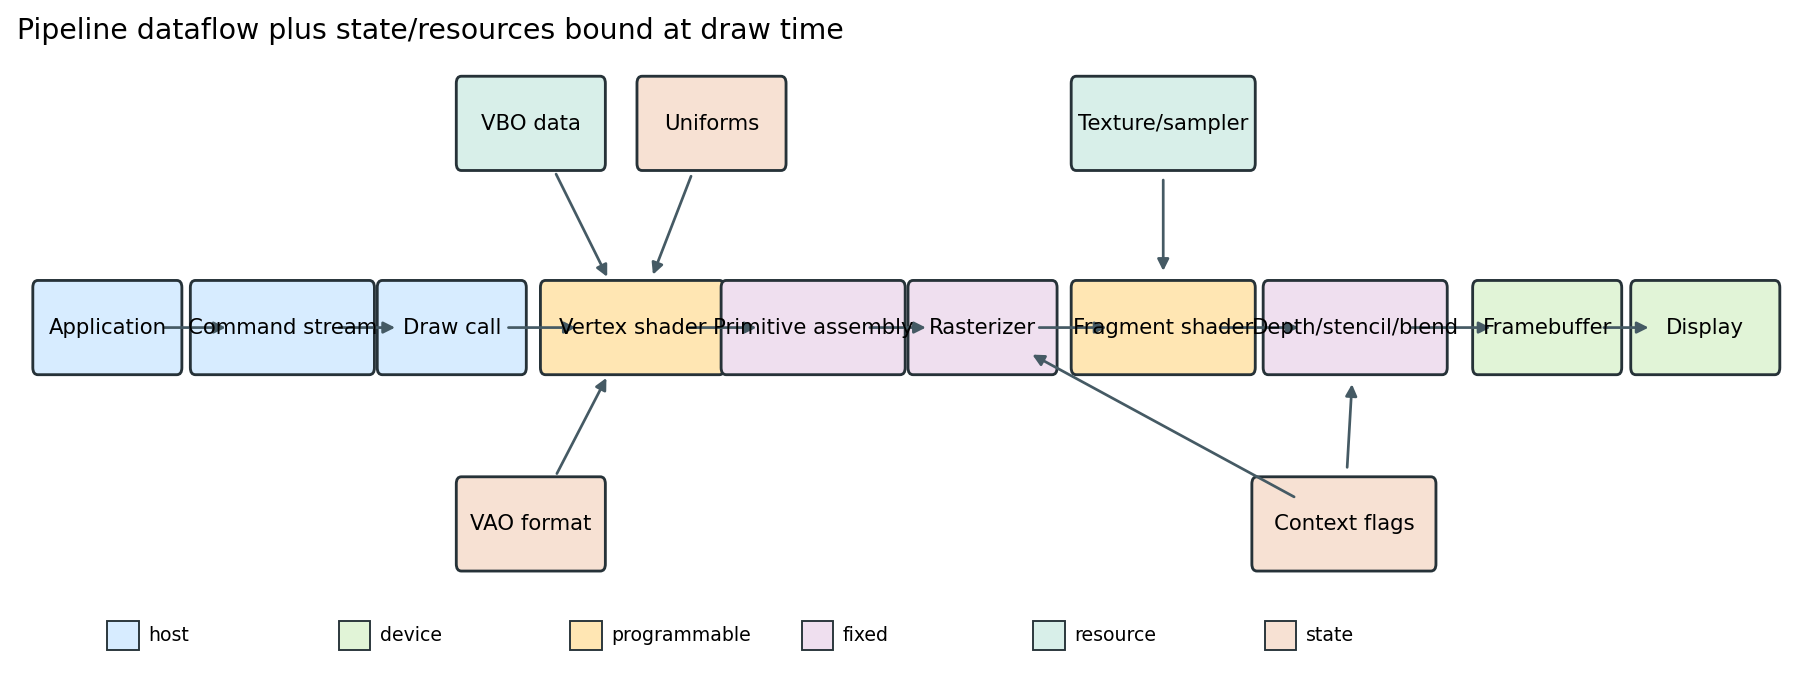

,stage,side,inspect,state_dependency
0,Application,host,Does the render loop issue commands in the int...,window/context exists
1,Draw call,host to device,"Which VAO, program, textures, and tests are ac...",bound state snapshot
2,Vertex shader,device programmable,Do attributes and uniforms produce plausible c...,"VBO, VAO, uniforms"
3,Rasterizer,device fixed,Which fragments exist and what barycentric wei...,"primitive mode, culling, viewport"
4,Fragment shader,device programmable,"Are normals, UVs, and texture samples meaningful?","interpolants, sampler state"
5,Depth/stencil/blend,device fixed,Which candidate fragments survive tests and bl...,"depth, stencil, blend state"
6,Framebuffer,device memory,Do color/depth/stencil attachments contain non...,display or offscreen target


In [4]:
display_artifact(pipeline_fig, width=920)
display(pd.DataFrame(pipeline_rows))
display_artifact(pipeline_check)


## 2. Buffers, Vertex Arrays, and the Cost of a Wrong Stride

Graphics hardware likes long contiguous arrays. The programmer's job is to tell the pipeline how bytes in those arrays should be interpreted. A vertex buffer object is storage; a vertex array object is the interpretation state: attribute location, component count, scalar type, stride, and byte offset.

The next synthetic buffer interleaves position, normal, color, and texture coordinates. This is not a recommendation that every application must interleave data; it is a compact way to see why a single wrong offset or stride can make a mesh look shredded, black, or randomly colored.


In [5]:
vertex_dtype = np.dtype([
    ("position", "<f4", 3), ("normal", "<f4", 3), ("color", "<f4", 3), ("uv", "<f4", 2),
], align=False)
vertices = np.array([
    ((-0.65, -0.55, 0.0), (0.0, 0.0, 1.0), (0.95, 0.18, 0.10), (0.00, 0.00)),
    (( 0.72, -0.45, 0.0), (0.0, 0.0, 1.0), (0.10, 0.70, 0.25), (1.00, 0.05)),
    ((-0.08,  0.78, 0.0), (0.0, 0.0, 1.0), (0.20, 0.34, 0.95), (0.42, 1.00)),
], dtype=vertex_dtype)
attribute_specs = [
    {"location": 0, "attribute": "position", "components": 3, "glsl_type": "vec3"},
    {"location": 1, "attribute": "normal", "components": 3, "glsl_type": "vec3"},
    {"location": 2, "attribute": "color", "components": 3, "glsl_type": "vec3"},
    {"location": 3, "attribute": "uv", "components": 2, "glsl_type": "vec2"},
]
stride = vertex_dtype.itemsize
offsets = {name: int(vertex_dtype.fields[name][1]) for name in vertex_dtype.names}
for row in attribute_specs:
    row["stride_bytes"] = stride
    row["offset_bytes"] = offsets[row["attribute"]]
    row["byte_range_in_vertex"] = f"{row['offset_bytes']}..{row['offset_bytes'] + row['components'] * 4 - 1}"
vao_table = save_table(attribute_specs, "vao-attribute-state.csv")
raw = vertices.tobytes()

def read_vec3(raw_bytes, vertex_index, offset, read_stride):
    start = vertex_index * read_stride + offset
    return np.frombuffer(raw_bytes[start:start + 12], dtype="<f4")

wrong_stride = stride - 12
intended_colors = np.vstack(vertices["color"])
wrong_stride_colors = np.vstack([read_vec3(raw, i, offsets["color"], wrong_stride) for i in range(len(vertices))])
wrong_stride_color_error = float(np.linalg.norm(intended_colors - np.clip(wrong_stride_colors, 0, 1)))

fig, ax = plt.subplots(figsize=(12, 3.5))
segments = [("position", 3, "#83b6d8"), ("normal", 3, "#9bd7a0"), ("color", 3, "#f2bd6b"), ("uv", 2, "#c4a7d8")]
y0 = 1.0
for vertex_index in range(3):
    base = vertex_index * stride
    ax.add_patch(Rectangle((base, y0), stride, 0.62, facecolor="#fafafa", edgecolor="#263238", linewidth=1.0))
    ax.text(base + stride / 2, y0 + 0.82, f"vertex {vertex_index}", ha="center", va="bottom", fontsize=9)
    x = base
    for name, comps, color in segments:
        width = comps * 4
        ax.add_patch(Rectangle((x, y0), width, 0.62, facecolor=color, edgecolor="white", linewidth=1.0))
        ax.text(x + width / 2, y0 + 0.31, name, ha="center", va="center", fontsize=8)
        ax.text(x, y0 - 0.14, str(x - base), ha="center", va="top", fontsize=7, color="#37474f")
        x += width
    ax.text(base + stride, y0 - 0.14, str(stride), ha="center", va="top", fontsize=7, color="#37474f")
ax.annotate(f"correct stride = {stride} bytes", xy=(stride, 1.76), xytext=(stride * 1.25, 2.45), arrowprops=dict(arrowstyle="->", color="#263238"), fontsize=10)
ax.annotate(f"bug example: stride {wrong_stride} reads later vertices at the wrong byte boundary", xy=(wrong_stride + offsets["color"], 1.02), xytext=(stride * 1.55, 0.32), arrowprops=dict(arrowstyle="->", color="#b23a48"), color="#b23a48", fontsize=9)
ax.set_xlim(-4, stride * 3 + 4)
ax.set_ylim(0.05, 2.8)
ax.set_xlabel("byte offset in the VBO")
ax.set_yticks([])
ax.set_title("Interleaved vertex buffer and the VAO attributes that decode it", loc="left")
buffer_fig = save_figure(fig, "vertex-buffer-array-layout.png")
buffer_checks = {
    "vertex_count": int(len(vertices)), "stride_bytes": int(stride), "offsets": offsets,
    "vao_locations": {row["attribute"]: row["location"] for row in attribute_specs},
    "wrong_stride_bytes": int(wrong_stride), "wrong_stride_color_error_l2": wrong_stride_color_error,
    "stride_matches_dtype_itemsize": bool(stride == vertex_dtype.itemsize),
    "offsets_are_monotone": bool([offsets[name] for name in vertex_dtype.names] == sorted(offsets.values())),
}
buffer_check = save_check("buffer-vao-layout-checks.json", buffer_checks)
print(pd.DataFrame(attribute_specs).to_string(index=False))
print(json.dumps(buffer_checks, indent=2))


 location attribute  components glsl_type  stride_bytes  offset_bytes byte_range_in_vertex
        0  position           3      vec3            44             0                0..11
        1    normal           3      vec3            44            12               12..23
        2     color           3      vec3            44            24               24..35
        3        uv           2      vec2            44            36               36..43
{
  "vertex_count": 3,
  "stride_bytes": 44,
  "offsets": {
    "position": 0,
    "normal": 12,
    "color": 24,
    "uv": 36
  },
  "vao_locations": {
    "position": 0,
    "normal": 1,
    "color": 2,
    "uv": 3
  },
  "wrong_stride_bytes": 32,
  "wrong_stride_color_error_l2": 1.4827675819396973,
  "stride_matches_dtype_itemsize": true,
  "offsets_are_monotone": true
}


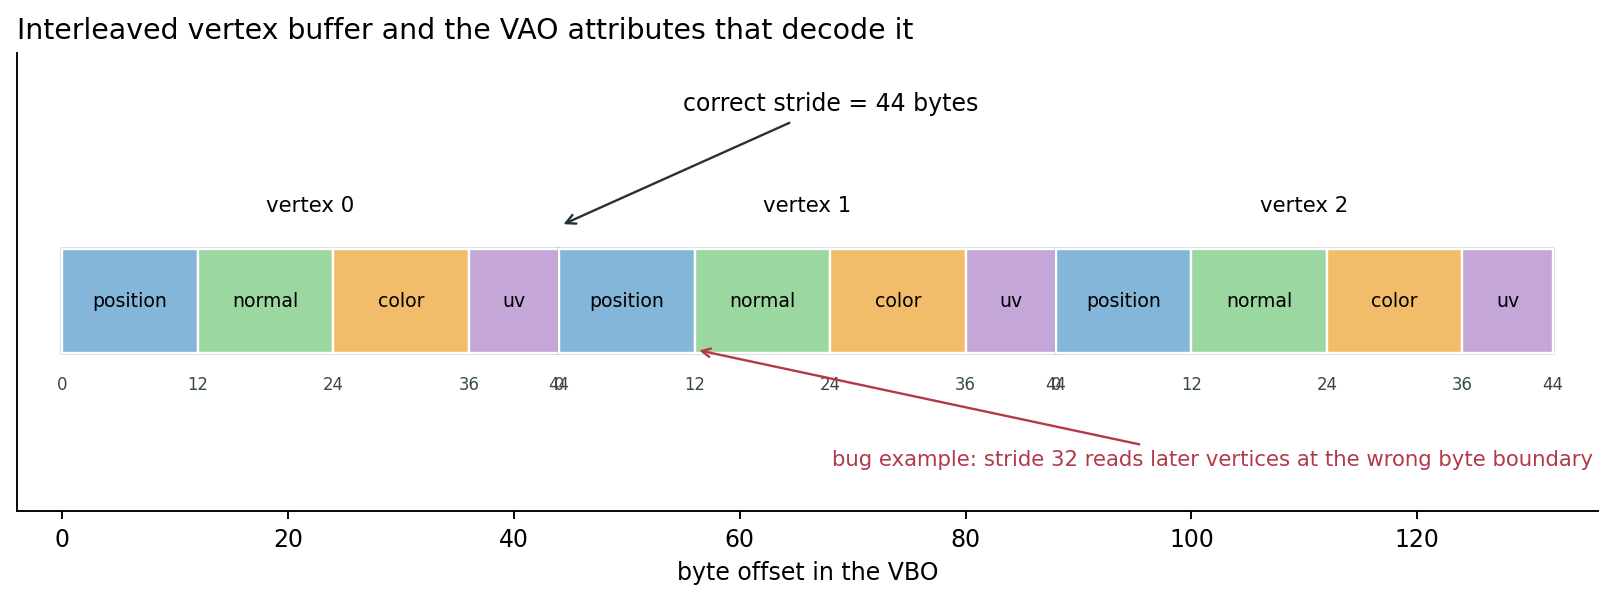

,location,attribute,components,glsl_type,stride_bytes,offset_bytes,byte_range_in_vertex
0,0,position,3,vec3,44,0,0..11
1,1,normal,3,vec3,44,12,12..23
2,2,color,3,vec3,44,24,24..35
3,3,uv,2,vec2,44,36,36..43


In [6]:
display_artifact(buffer_fig, width=900)
display(pd.DataFrame(attribute_specs))
display_artifact(buffer_check)


## 3. Transform Uniforms: Local Data Becomes Clip-Space Data

Modern OpenGL-style code no longer relies on a hidden matrix stack. The host prepares model, view, and projection matrices, sends them as uniforms, and the vertex shader applies them. In column-vector notation, the central computation is

\[
    p_{clip} = P\,V\,M\,[x\;y\;z\;1]^T,\qquad
    p_{ndc} = p_{clip}/w.
\]

The interactive artifact below uses a Trimesh box as the vertex data. The same vertices are shown after the model-view-projection chain, with a shifted copy of the normalized device coordinate box so that clip results can be inspected alongside the world-space mesh.


In [7]:
def translation(tx, ty, tz):
    M = np.eye(4)
    M[:3, 3] = [tx, ty, tz]
    return M


def scale(sx, sy, sz):
    return np.diag([sx, sy, sz, 1.0])


def rotation_y(theta_degrees):
    t = math.radians(theta_degrees)
    c, s = math.cos(t), math.sin(t)
    M = np.eye(4)
    M[0, 0] = c
    M[0, 2] = s
    M[2, 0] = -s
    M[2, 2] = c
    return M


def look_at(eye, target, up):
    eye = np.asarray(eye, dtype=float)
    target = np.asarray(target, dtype=float)
    up = np.asarray(up, dtype=float)
    f = normalize(target - eye)
    s = normalize(np.cross(f, up))
    u = np.cross(s, f)
    M = np.eye(4)
    M[0, :3] = s
    M[1, :3] = u
    M[2, :3] = -f
    M[:3, 3] = -M[:3, :3] @ eye
    return M


def perspective(fovy_degrees, aspect, near, far):
    f = 1.0 / math.tan(math.radians(fovy_degrees) / 2.0)
    M = np.zeros((4, 4))
    M[0, 0] = f / aspect
    M[1, 1] = f
    M[2, 2] = (far + near) / (near - far)
    M[2, 3] = (2 * far * near) / (near - far)
    M[3, 2] = -1.0
    return M

mesh = trimesh.creation.box(extents=(1.2, 0.82, 0.7))
local_vertices = mesh.vertices
faces = mesh.faces
M_model = translation(0.0, 0.05, 0.0) @ rotation_y(28) @ scale(1.0, 1.12, 0.88)
M_view = look_at([2.6, 1.75, 3.2], [0.0, 0.0, 0.0], [0.0, 1.0, 0.0])
M_proj = perspective(52, aspect=16 / 10, near=0.1, far=8.0)
MVP = M_proj @ M_view @ M_model
world_h = transform_points(M_model, local_vertices)
clip_h = (MVP @ homogeneous(local_vertices).T).T
ndc = clip_h[:, :3] / clip_h[:, 3:4]
depth01 = 0.5 * ndc[:, 2] + 0.5
world_vertices = world_h[:, :3]
ndc_shift = ndc.copy()
ndc_shift[:, 0] += 2.6

fig3d = go.Figure()
fig3d.add_trace(go.Mesh3d(x=world_vertices[:, 0], y=world_vertices[:, 1], z=world_vertices[:, 2], i=faces[:, 0], j=faces[:, 1], k=faces[:, 2], color="#6aa6d8", opacity=0.62, name="world mesh", flatshading=True))
fig3d.add_trace(go.Mesh3d(x=ndc_shift[:, 0], y=ndc_shift[:, 1], z=ndc_shift[:, 2], i=faces[:, 0], j=faces[:, 1], k=faces[:, 2], color="#f1a55b", opacity=0.48, name="NDC mesh shifted right", flatshading=True))
cube = np.array([[-1,-1,-1],[1,-1,-1],[1,1,-1],[-1,1,-1],[-1,-1,1],[1,-1,1],[1,1,1],[-1,1,1]], dtype=float)
cube[:, 0] += 2.6
for a, b in [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),(0,4),(1,5),(2,6),(3,7)]:
    fig3d.add_trace(go.Scatter3d(x=[cube[a,0], cube[b,0]], y=[cube[a,1], cube[b,1]], z=[cube[a,2], cube[b,2]], mode="lines", line=dict(color="#444", width=3), showlegend=False))
for idx in range(len(local_vertices)):
    fig3d.add_trace(go.Scatter3d(x=[world_vertices[idx,0], ndc_shift[idx,0]], y=[world_vertices[idx,1], ndc_shift[idx,1]], z=[world_vertices[idx,2], ndc_shift[idx,2]], mode="lines", line=dict(color="rgba(70,70,70,0.26)", width=2), showlegend=False))
fig3d.update_layout(title="Model-view-projection chain: world mesh and shifted NDC result", scene=dict(aspectmode="data", xaxis_title="x", yaxis_title="y", zaxis_title="z"), margin=dict(l=0, r=0, t=44, b=0), height=620)
transform_html = remember(save_plotly_html(fig3d, TOPIC, "model-view-projection-chain.html", include_plotlyjs="cdn"))

viewport_w, viewport_h = 800, 500
screen_xy = np.c_[(ndc[:, 0] * 0.5 + 0.5) * viewport_w, (1.0 - (ndc[:, 1] * 0.5 + 0.5)) * viewport_h]
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
axes[0].scatter(screen_xy[:, 0], screen_xy[:, 1], c=depth01, cmap="viridis", s=82, edgecolor="black")
for tri in faces:
    tri_xy = screen_xy[tri]
    axes[0].plot(*np.vstack([tri_xy, tri_xy[0]]).T, color="#546e7a", linewidth=1.0, alpha=0.7)
axes[0].set_xlim(0, viewport_w); axes[0].set_ylim(viewport_h, 0); axes[0].set_aspect("equal")
axes[0].set_title("Viewport coordinates"); axes[0].set_xlabel("screen x"); axes[0].set_ylabel("screen y")
axes[1].scatter(ndc[:, 0], ndc[:, 1], c=depth01, cmap="viridis", s=82, edgecolor="black")
axes[1].add_patch(Rectangle((-1, -1), 2, 2, fill=False, edgecolor="#37474f", linewidth=1.4))
axes[1].set_xlim(-1.15, 1.15); axes[1].set_ylim(-1.15, 1.15); axes[1].set_aspect("equal")
axes[1].set_title("NDC x/y colored by depth"); axes[1].set_xlabel("ndc x"); axes[1].set_ylabel("ndc y")
fig.suptitle("Clip divide and viewport mapping", x=0.05, ha="left")
viewport_fig = save_figure(fig, "clip-space-viewport-depth.png")
transform_checks = {
    "clip_w_min": float(clip_h[:, 3].min()),
    "clip_w_all_positive": bool(np.all(clip_h[:, 3] > 0)),
    "ndc_min": ndc.min(axis=0).round(6).tolist(),
    "ndc_max": ndc.max(axis=0).round(6).tolist(),
    "all_vertices_inside_clip_cube": bool(np.all(np.abs(ndc[:, :2]) <= 1.0 + 1e-9) and np.all((ndc[:, 2] >= -1.0 - 1e-9) & (ndc[:, 2] <= 1.0 + 1e-9))),
    "depth01_minmax": [float(depth01.min()), float(depth01.max())],
    "viewport_width_height": [viewport_w, viewport_h],
}
transform_check = save_check("model-view-projection-checks.json", transform_checks)
print(json.dumps(transform_checks, indent=2))


{
  "clip_w_min": 3.8956777508731903,
  "clip_w_all_positive": true,
  "ndc_min": [
    -0.202141,
    -0.260171,
    0.973328
  ],
  "ndc_max": [
    0.186527,
    0.277754,
    0.985
  ],
  "all_vertices_inside_clip_cube": true,
  "depth01_minmax": [
    0.9866638234695274,
    0.9924997616880198
  ],
  "viewport_width_height": [
    800,
    500
  ]
}


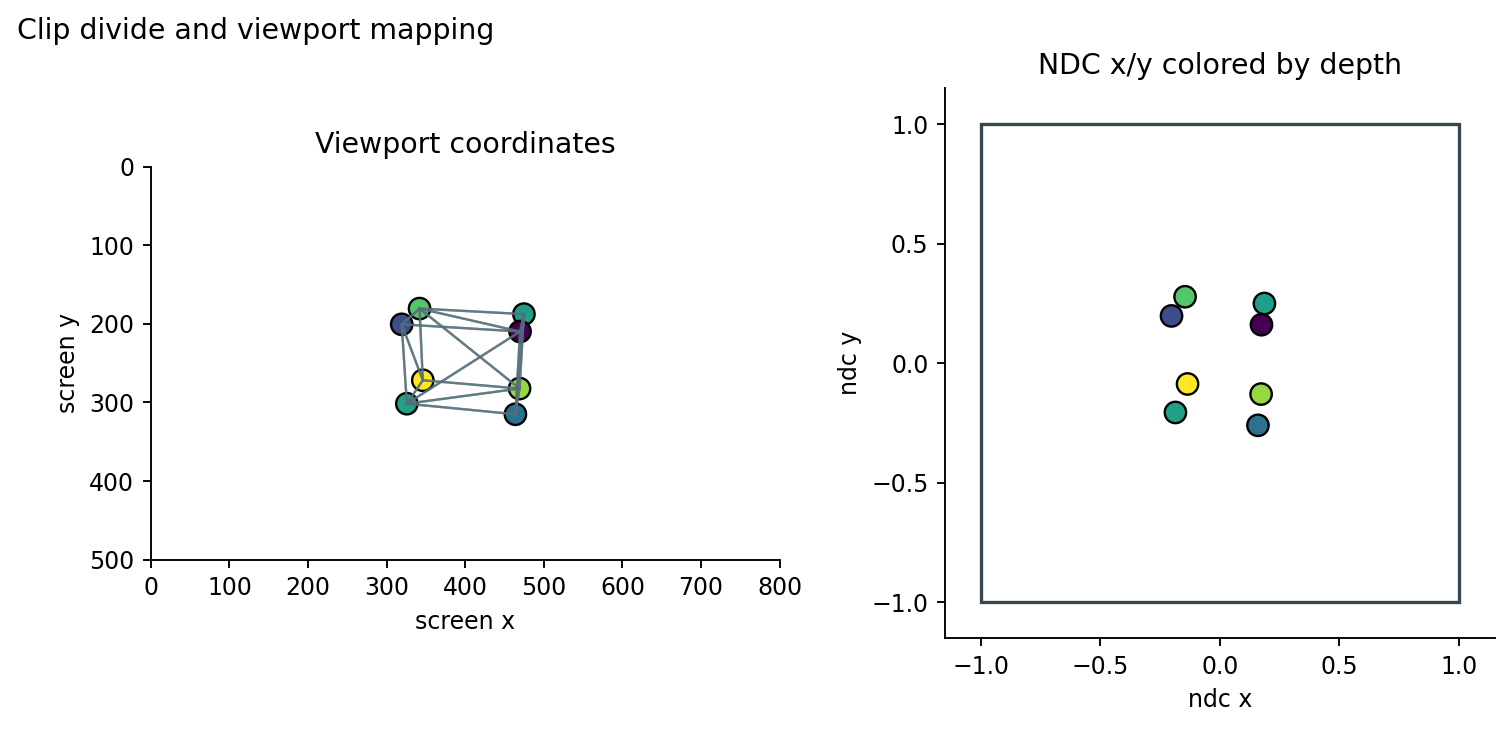

In [8]:
display_artifact(transform_html, width="100%", height=560)
display_artifact(viewport_fig, width=780)
display_artifact(transform_check)


## 4. Rasterization, Depth, and Stencil Are Context, Not Shaders

After vertex shading and primitive assembly, triangles become candidate fragments. Each candidate fragment carries interpolated attributes, a depth value, and whatever stencil/depth/blend state the context says should be applied. The following software rasterizer renders two overlapping triangles, keeps the nearest depth, writes a stencil label for the triangle that survived, and counts overdraw.

This is the same debugging habit used on real hardware: make each hidden buffer visible. Color tells you what survived shading, depth tells you what won visibility, stencil tells you which label or mask was written, and overdraw tells you how much discarded work happened.


In [9]:
def rasterize_triangles(triangles, width=260, height=180):
    yy, xx = np.mgrid[0:height, 0:width]
    points = np.stack([xx + 0.5, yy + 0.5], axis=-1)
    color = np.ones((height, width, 3), dtype=float) * np.array([0.96, 0.965, 0.955])
    depth = np.ones((height, width), dtype=float)
    stencil = np.zeros((height, width), dtype=np.int32)
    overdraw = np.zeros((height, width), dtype=np.int32)
    max_bary_error = 0.0
    for tri_id, tri in enumerate(triangles, start=1):
        xy = np.asarray(tri["xy"], dtype=float); z = np.asarray(tri["z"], dtype=float); rgb = np.asarray(tri["color"], dtype=float)
        bary = barycentric_coordinates(points, xy)
        inside = np.all(bary >= -1e-9, axis=-1)
        if np.any(inside):
            max_bary_error = max(max_bary_error, float(np.max(np.abs(bary[inside].sum(axis=-1) - 1.0))))
        candidate_depth = np.tensordot(bary, z, axes=([-1], [0]))
        candidate_color = np.clip(np.tensordot(bary, rgb, axes=([-1], [0])), 0.0, 1.0)
        overdraw[inside] += 1
        pass_depth = inside & (candidate_depth < depth)
        depth[pass_depth] = candidate_depth[pass_depth]
        color[pass_depth] = candidate_color[pass_depth]
        stencil[pass_depth] = tri_id
    return color, depth, stencil, overdraw, max_bary_error

triangles = [
    {"name": "far warm triangle", "xy": np.array([[34,36], [224,48], [96,164]], dtype=float), "z": np.array([0.66, 0.63, 0.70]), "color": np.array([[0.95,0.20,0.12], [0.98,0.66,0.15], [0.80,0.16,0.35]])},
    {"name": "near cool triangle", "xy": np.array([[82,26], [236,136], [38,146]], dtype=float), "z": np.array([0.36, 0.31, 0.43]), "color": np.array([[0.10,0.40,0.95], [0.08,0.72,0.82], [0.42,0.24,0.78]])},
]
color_buffer, depth_buffer, stencil_buffer, overdraw_buffer, bary_error = rasterize_triangles(triangles)
sample_xy = np.array([120.5, 90.5])
sample_barys = [barycentric_coordinates(sample_xy, tri["xy"]) for tri in triangles]
sample_inside = [bool(np.all(b >= -1e-9)) for b in sample_barys]
sample_depths = [float(np.dot(b, tri["z"])) for b, tri in zip(sample_barys, triangles)]
sample_winner = int(np.argmin(sample_depths) + 1) if all(sample_inside) else int(stencil_buffer[int(sample_xy[1]), int(sample_xy[0])])
fig, axes = plt.subplots(1, 4, figsize=(14.5, 4.0), constrained_layout=True)
for ax, image, title, cmap in [
    (axes[0], color_buffer, "Color buffer", None), (axes[1], depth_buffer, "Depth buffer", "magma_r"),
    (axes[2], stencil_buffer, "Stencil labels", "tab20"), (axes[3], overdraw_buffer, "Overdraw count", "viridis")]:
    ax.imshow(image, origin="upper", cmap=cmap)
    ax.scatter([sample_xy[0]], [sample_xy[1]], c="white", edgecolor="black", s=45, zorder=4)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Two triangles through rasterization, depth test, and stencil write", x=0.04, ha="left")
raster_fig = save_figure(fig, "depth-stencil-rasterization-context.png")
raster_checks = {
    "image_shape": list(color_buffer.shape), "max_barycentric_sum_error": bary_error,
    "sample_xy": sample_xy.tolist(), "sample_inside_both_triangles": bool(all(sample_inside)),
    "sample_depths_by_triangle": sample_depths, "sample_winner_triangle_id": sample_winner,
    "stencil_values": sorted(map(int, np.unique(stencil_buffer))),
    "overdraw_pixels": int(np.count_nonzero(overdraw_buffer > 1)), "visible_pixels": int(np.count_nonzero(stencil_buffer)),
}
raster_check = save_check("depth-stencil-rasterization-checks.json", raster_checks)
print(json.dumps(raster_checks, indent=2))


{
  "image_shape": [
    180,
    260,
    3
  ],
  "max_barycentric_sum_error": 2.220446049250313e-16,
  "sample_xy": [
    120.5,
    90.5
  ],
  "sample_inside_both_triangles": true,
  "sample_depths_by_triangle": [
    0.666018408551069,
    0.3611132075471698
  ],
  "sample_winner_triangle_id": 2,
  "stencil_values": [
    0,
    1,
    2
  ],
  "overdraw_pixels": 7440,
  "visible_pixels": 16020
}


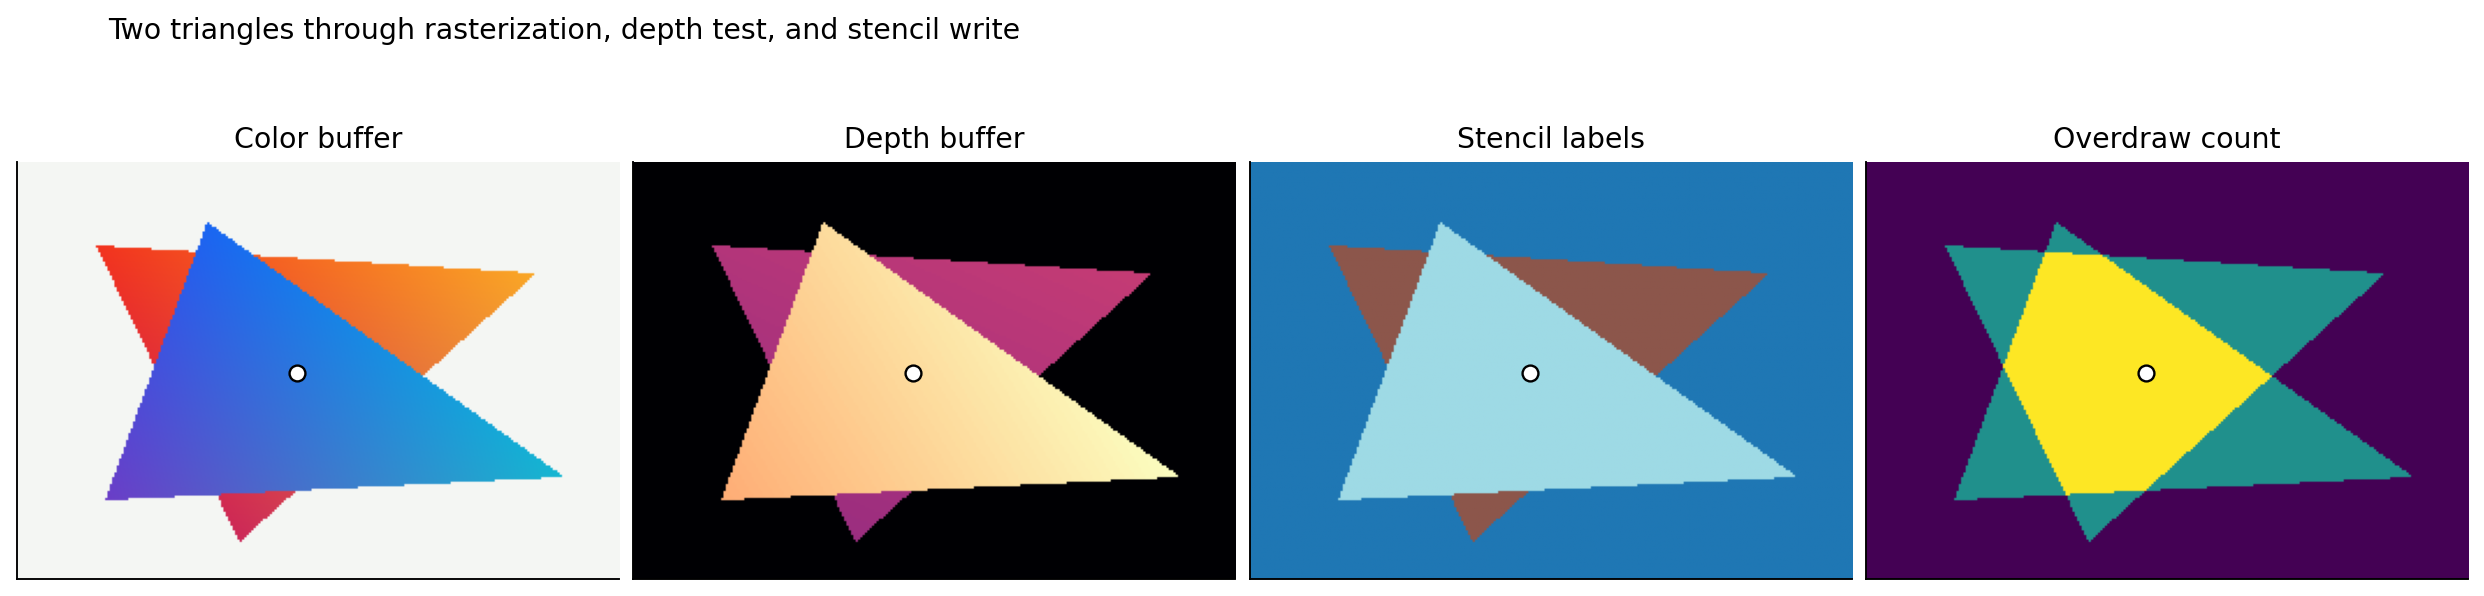

In [10]:
display_artifact(raster_fig, width=960)
display_artifact(raster_check)


## 5. Attributes, Interpolation, and Visual Shader Debugging

A shader can only use the values the pipeline feeds it. Vertex attributes are read according to VAO state, interpolated across the primitive, and then consumed by the fragment shader. A common debugging move is to temporarily ignore the intended material and output a diagnostic value: vertex color, encoded normal, UV coordinates, or a flat constant.

The artifact below shows four fragment outputs for one triangle: intended color interpolation, normal-as-color debugging, UV-as-color debugging, and a simulated stride/offset mistake. The fourth image is not a rendering style; it is what a bad attribute decode can look like when the shader faithfully colors with corrupted inputs.


In [11]:
attr_width, attr_height = 240, 210
tri_xy = np.array([[35, 176], [210, 164], [118, 28]], dtype=float)
yy, xx = np.mgrid[0:attr_height, 0:attr_width]
points = np.stack([xx + 0.5, yy + 0.5], axis=-1)
bary = barycentric_coordinates(points, tri_xy)
inside = np.all(bary >= -1e-9, axis=-1)
vertex_colors = intended_colors.copy()
vertex_normals = normalize(np.array([[-0.42, 0.12, 0.90], [0.50, 0.28, 0.82], [0.03, 0.86, 0.50]], dtype=float))
vertex_uv = np.vstack(vertices["uv"])
color_img = np.ones((attr_height, attr_width, 3)) * 0.96
normal_img = np.ones_like(color_img) * 0.96
bug_img = np.ones_like(color_img) * 0.96
uv_img = np.ones_like(color_img) * 0.96
interp_color = np.tensordot(bary, vertex_colors, axes=([-1], [0]))
interp_normals = np.tensordot(bary, vertex_normals, axes=([-1], [0]))
unit_normals = normalize(interp_normals)
encoded_normals = 0.5 * unit_normals + 0.5
interp_uv = np.tensordot(bary, vertex_uv, axes=([-1], [0]))
wrong_vertex_colors = np.clip(wrong_stride_colors, 0.0, 1.0)
interp_bug = np.tensordot(bary, wrong_vertex_colors, axes=([-1], [0]))
color_img[inside] = np.clip(interp_color[inside], 0, 1)
normal_img[inside] = np.clip(encoded_normals[inside], 0, 1)
uv_img[inside] = np.dstack([interp_uv[..., 0], interp_uv[..., 1], np.full_like(interp_uv[..., 0], 0.38)])[inside]
bug_img[inside] = np.clip(interp_bug[inside], 0, 1)
fig, axes = plt.subplots(1, 4, figsize=(14.2, 4.0), constrained_layout=True)
for ax, image, title in [(axes[0], color_img, "attribute color"), (axes[1], normal_img, "normal shader"), (axes[2], uv_img, "UV as color"), (axes[3], bug_img, "wrong stride")]:
    ax.imshow(image, origin="upper")
    ax.plot(*np.vstack([tri_xy, tri_xy[0]]).T, color="black", linewidth=1.0)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Fragment shader debug outputs from the same triangle", x=0.04, ha="left")
attribute_fig = save_figure(fig, "shader-attribute-interpolation-debug.png")
normal_lengths = np.linalg.norm(unit_normals[inside], axis=-1)
attr_checks = {
    "inside_pixel_count": int(np.count_nonzero(inside)),
    "max_barycentric_sum_error": float(np.max(np.abs(bary[inside].sum(axis=-1) - 1.0))),
    "interpolated_color_minmax": [float(interp_color[inside].min()), float(interp_color[inside].max())],
    "normal_length_minmax_after_normalize": [float(normal_lengths.min()), float(normal_lengths.max())],
    "uv_minmax_inside": [float(interp_uv[inside].min()), float(interp_uv[inside].max())],
    "wrong_stride_color_l2_error": wrong_stride_color_error,
    "mean_abs_bug_image_difference": float(np.mean(np.abs(color_img[inside] - bug_img[inside]))),
}
attribute_check = save_check("shader-attribute-interpolation-checks.json", attr_checks)
print(json.dumps(attr_checks, indent=2))


{
  "inside_pixel_count": 12452,
  "max_barycentric_sum_error": 2.220446049250313e-16,
  "interpolated_color_minmax": [
    0.10112632657220268,
    0.9464363035966707
  ],
  "normal_length_minmax_after_normalize": [
    0.9999999999999998,
    1.0000000000000002
  ],
  "uv_minmax_inside": [
    0.00222956154376108,
    0.996939045887164
  ],
  "wrong_stride_color_l2_error": 1.4827675819396973,
  "mean_abs_bug_image_difference": 0.1956884068273412
}


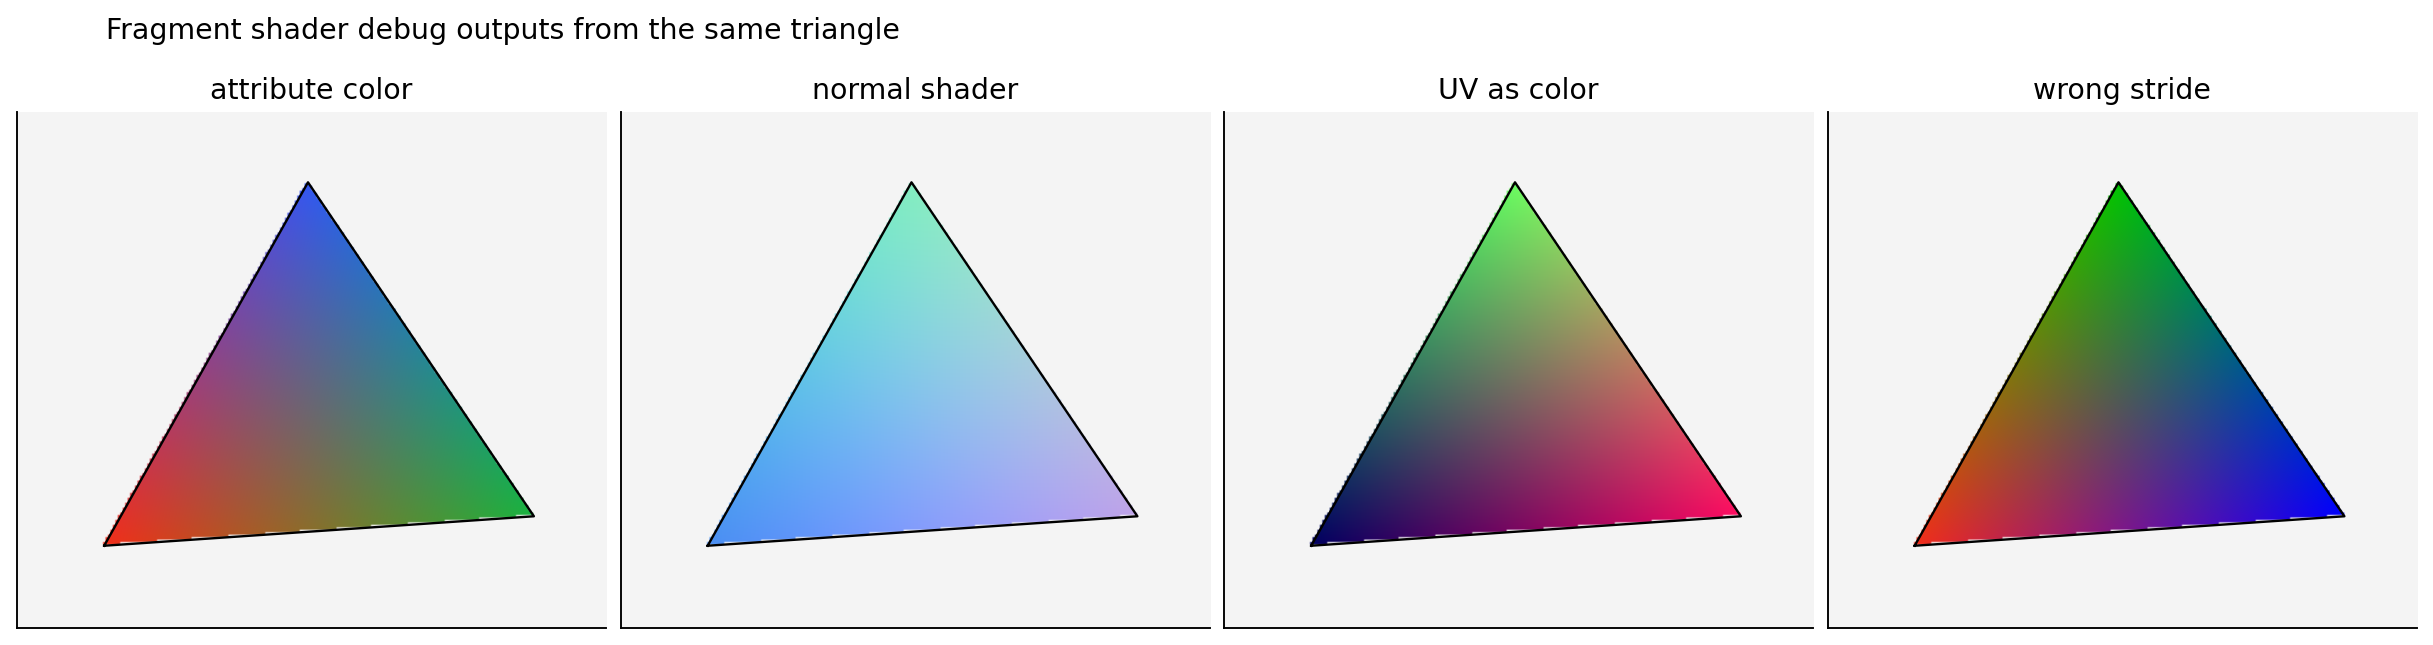

In [12]:
display_artifact(attribute_fig, width=960)
display_artifact(attribute_check)


## 6. Texture Objects: UVs, Samplers, and Wrapping State

A texture object is image-like data stored on the device, but the visual result depends on more than the image. The fragment shader supplies coordinates; the sampler state decides what happens outside the nominal range and how samples between texels are filtered. This is why changing wrap state can tile a ground plane without changing the shader source.

The next artifact uses a synthetic checker texture so that no external image is required. The panels compare clamping outside the coordinate range, repeating over several tiles, and bilinear magnification.


In [13]:
tex_size = 128
y, x = np.mgrid[0:tex_size, 0:tex_size]
checker = ((x // 8 + y // 8) % 2).astype(float)
texture = np.zeros((tex_size, tex_size, 3), dtype=np.uint8)
texture[..., 0] = np.clip(np.where(checker > 0, 206, 42) + ((3 * x + 2 * y) % 31), 0, 255)
texture[..., 1] = np.clip(np.where((x % 16) < 3, 226, 68 + ((5 * x + y) % 132)), 0, 255)
texture[..., 2] = np.clip(np.where((y % 16) < 3, 236, 74 + ((x + 7 * y) % 126)), 0, 255)
texture_data = remember(save_image(texture, TOPIC, "synthetic-uv-checker-texture.png", kind="data"))

def wrap_uv(uv, mode):
    uv = np.asarray(uv, dtype=float)
    if mode == "repeat": return uv % 1.0
    if mode == "clamp": return np.clip(uv, 0.0, 1.0)
    raise ValueError(mode)


def sample_texture(tex, uv, *, wrap="repeat", filter_mode="nearest"):
    tex = np.asarray(tex, dtype=float) / 255.0
    uv_wrapped = wrap_uv(uv, wrap)
    h, w = tex.shape[:2]
    sx = uv_wrapped[..., 0] * (w - 1)
    sy = (1.0 - uv_wrapped[..., 1]) * (h - 1)
    if filter_mode == "nearest":
        return tex[np.rint(sy).astype(int), np.rint(sx).astype(int)]
    if filter_mode == "bilinear":
        x0 = np.floor(sx).astype(int); y0 = np.floor(sy).astype(int)
        x1 = np.clip(x0 + 1, 0, w - 1); y1 = np.clip(y0 + 1, 0, h - 1)
        tx = sx - x0; ty = sy - y0
        c00 = tex[y0, x0]; c10 = tex[y0, x1]; c01 = tex[y1, x0]; c11 = tex[y1, x1]
        return (1 - tx)[..., None] * (1 - ty)[..., None] * c00 + tx[..., None] * (1 - ty)[..., None] * c10 + (1 - tx)[..., None] * ty[..., None] * c01 + tx[..., None] * ty[..., None] * c11
    raise ValueError(filter_mode)


def uv_grid(width, height, u0, u1, v0, v1):
    yy, xx = np.mgrid[0:height, 0:width]
    u = u0 + (u1 - u0) * xx / max(width - 1, 1)
    v = v0 + (v1 - v0) * (1 - yy / max(height - 1, 1))
    return np.stack([u, v], axis=-1)

uv_clamp = uv_grid(190, 150, -0.35, 1.35, -0.25, 1.25)
uv_repeat = uv_grid(190, 150, 0.0, 5.0, 0.0, 5.0)
uv_zoom = uv_grid(190, 150, 0.18, 0.42, 0.22, 0.48)
clamp_img = sample_texture(texture, uv_clamp, wrap="clamp", filter_mode="nearest")
repeat_img = sample_texture(texture, uv_repeat, wrap="repeat", filter_mode="nearest")
bilinear_img = sample_texture(texture, uv_zoom, wrap="repeat", filter_mode="bilinear")
nearest_zoom = sample_texture(texture, uv_zoom, wrap="repeat", filter_mode="nearest")
fig, axes = plt.subplots(1, 4, figsize=(14.0, 4.0), constrained_layout=True)
for ax, image, title in [(axes[0], texture, "texture data"), (axes[1], clamp_img, "clamp outside [0,1]"), (axes[2], repeat_img, "repeat over 5x5 UVs"), (axes[3], bilinear_img, "bilinear magnification")]:
    ax.imshow(image); ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Texture coordinates plus sampler state determine the lookup", x=0.04, ha="left")
texture_fig = save_figure(fig, "texture-coordinate-wrap-filtering.png")
periodic_a = sample_texture(texture, np.array([0.1875, 0.34375]), wrap="repeat", filter_mode="nearest")
periodic_b = sample_texture(texture, np.array([1.1875, 2.34375]), wrap="repeat", filter_mode="nearest")
clamp_a = sample_texture(texture, np.array([-0.4, 0.52]), wrap="clamp", filter_mode="nearest")
clamp_b = sample_texture(texture, np.array([0.0, 0.52]), wrap="clamp", filter_mode="nearest")
texture_checks = {
    "texture_shape": list(texture.shape),
    "repeat_periodic_sample_equal": bool(np.allclose(periodic_a, periodic_b)),
    "clamp_border_sample_equal": bool(np.allclose(clamp_a, clamp_b)),
    "bilinear_value_range": [float(bilinear_img.min()), float(bilinear_img.max())],
    "nearest_vs_bilinear_mean_abs_difference": float(np.mean(np.abs(nearest_zoom - bilinear_img))),
}
texture_check = save_check("texture-sampler-checks.json", texture_checks)
print(json.dumps(texture_checks, indent=2))


{
  "texture_shape": [
    128,
    128,
    3
  ],
  "repeat_periodic_sample_equal": true,
  "clamp_border_sample_equal": true,
  "bilinear_value_range": [
    0.1657346643355327,
    0.9254901960784316
  ],
  "nearest_vs_bilinear_mean_abs_difference": 0.027575536103731688
}


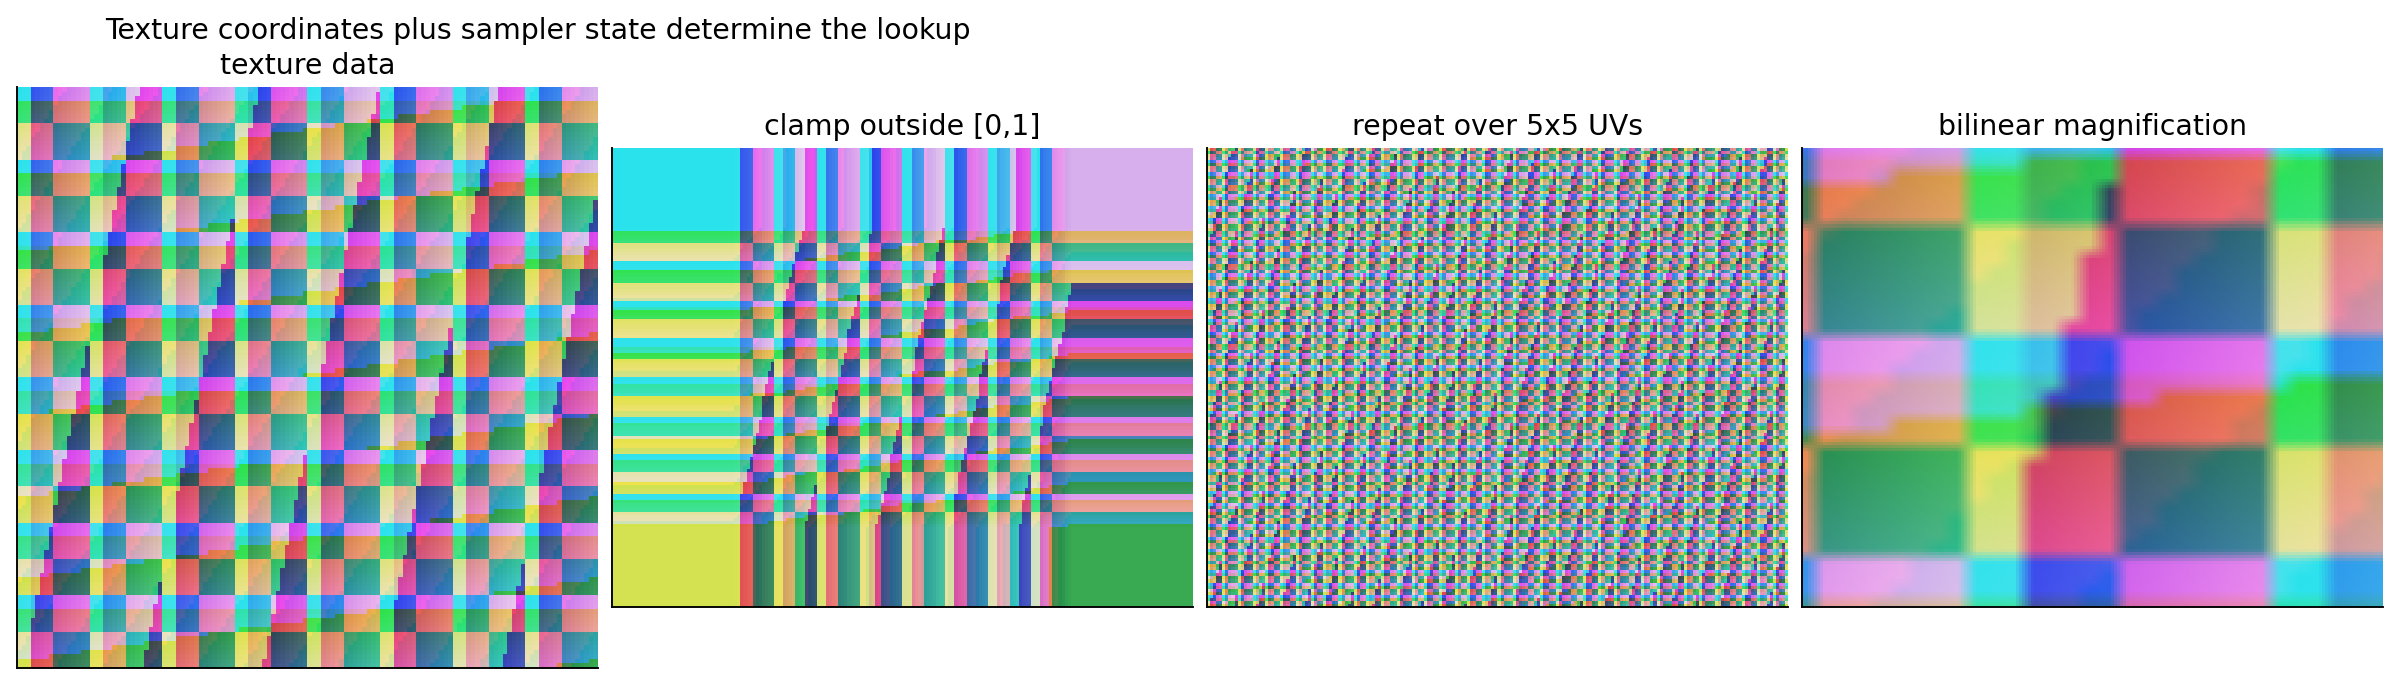

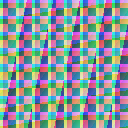

In [14]:
display_artifact(texture_fig, width=940)
display_artifact(texture_data, width=180)
display_artifact(texture_check)


## 7. Meshes and Instancing: One Geometry, Many Model Matrices

A mesh loaded from an OBJ-like source is usually transferred once into vertex/index buffers. Instancing then reuses that resident geometry with different model transforms, material uniforms, or per-instance attributes. This is the hardware-side counterpart to object instances in a ray tracer: the object data is shared, while each draw instance changes the transform and state.

The artifact below uses a single Trimesh icosphere. Plotly displays transformed copies, but the checks count the upload as one base mesh plus a small matrix per instance.


In [15]:
base_mesh = trimesh.creation.icosphere(subdivisions=2, radius=0.42)
base_vertices = np.asarray(base_mesh.vertices)
base_faces = np.asarray(base_mesh.faces)
base_normals = np.asarray(base_mesh.vertex_normals)
instances = [
    {"name": "sphere-left", "translation": (-1.35, 0.00, 0.00), "scale": (1.00, 1.00, 1.00), "rotation_y": 0, "color": "rgb(75,139,190)"},
    {"name": "ellipsoid-tall", "translation": (-0.42, 0.18, 0.05), "scale": (0.62, 1.42, 0.62), "rotation_y": 18, "color": "rgb(214,122,64)"},
    {"name": "sphere-center", "translation": (0.55, -0.03, -0.05), "scale": (0.84, 0.84, 0.84), "rotation_y": -25, "color": "rgb(101,166,118)"},
    {"name": "ellipsoid-wide", "translation": (1.55, 0.02, 0.02), "scale": (1.36, 0.56, 0.76), "rotation_y": 36, "color": "rgb(143,104,178)"},
    {"name": "small-sphere", "translation": (0.08, 0.88, -0.30), "scale": (0.46, 0.46, 0.46), "rotation_y": 0, "color": "rgb(210,186,82)"},
    {"name": "tilted-ellipsoid", "translation": (1.02, 0.82, -0.22), "scale": (0.48, 0.78, 1.05), "rotation_y": -42, "color": "rgb(205,91,116)"},
]
instance_rows = []
inst_fig = go.Figure()
normal_matrix_errors = []
for inst in instances:
    model = translation(*inst["translation"]) @ rotation_y(inst["rotation_y"]) @ scale(*inst["scale"])
    world = transform_points(model, base_vertices)[:, :3]
    normal_matrix = np.linalg.inv(model[:3, :3]).T
    transformed_normals = normalize((normal_matrix @ base_normals.T).T)
    normal_matrix_errors.append(float(abs(np.linalg.norm(transformed_normals[0]) - 1.0)))
    inst_fig.add_trace(go.Mesh3d(x=world[:, 0], y=world[:, 1], z=world[:, 2], i=base_faces[:, 0], j=base_faces[:, 1], k=base_faces[:, 2], color=inst["color"], opacity=0.74, flatshading=True, name=inst["name"]))
    instance_rows.append({
        "name": inst["name"], "tx": inst["translation"][0], "ty": inst["translation"][1], "tz": inst["translation"][2],
        "sx": inst["scale"][0], "sy": inst["scale"][1], "sz": inst["scale"][2], "rotation_y_degrees": inst["rotation_y"],
        "det_model_linear": float(np.linalg.det(model[:3, :3])), "base_vertex_count_reused": int(len(base_vertices)),
    })
inst_fig.update_layout(title="Instancing one resident mesh with six model transforms", scene=dict(aspectmode="data", xaxis_title="x", yaxis_title="y", zaxis_title="z"), margin=dict(l=0, r=0, t=44, b=0), height=620)
instancing_html = remember(save_plotly_html(inst_fig, TOPIC, "mesh-instancing-transform-table.html", include_plotlyjs="cdn"))
instance_table = save_table(instance_rows, "instance-transforms.csv")
naive_vertices_uploaded = len(base_vertices) * len(instances)
instanced_vertices_uploaded = len(base_vertices)
instancing_checks = {
    "base_vertex_count": int(len(base_vertices)), "base_face_count": int(len(base_faces)), "instance_count": int(len(instances)),
    "naive_vertices_if_duplicated": int(naive_vertices_uploaded), "vertices_uploaded_with_instancing": int(instanced_vertices_uploaded),
    "vertex_upload_reduction_fraction": float(1.0 - instanced_vertices_uploaded / naive_vertices_uploaded),
    "all_model_linear_parts_invertible": bool(all(row["det_model_linear"] > 0 for row in instance_rows)),
    "max_normal_matrix_unit_error": float(max(normal_matrix_errors)),
}
instancing_check = save_check("mesh-instancing-checks.json", instancing_checks)
print(pd.DataFrame(instance_rows).to_string(index=False))
print(json.dumps(instancing_checks, indent=2))


            name    tx    ty    tz   sx   sy   sz  rotation_y_degrees  det_model_linear  base_vertex_count_reused
     sphere-left -1.35  0.00  0.00 1.00 1.00 1.00                   0          1.000000                       162
  ellipsoid-tall -0.42  0.18  0.05 0.62 1.42 0.62                  18          0.545848                       162
   sphere-center  0.55 -0.03 -0.05 0.84 0.84 0.84                 -25          0.592704                       162
  ellipsoid-wide  1.55  0.02  0.02 1.36 0.56 0.76                  36          0.578816                       162
    small-sphere  0.08  0.88 -0.30 0.46 0.46 0.46                   0          0.097336                       162
tilted-ellipsoid  1.02  0.82 -0.22 0.48 0.78 1.05                 -42          0.393120                       162
{
  "base_vertex_count": 162,
  "base_face_count": 320,
  "instance_count": 6,
  "naive_vertices_if_duplicated": 972,
  "vertices_uploaded_with_instancing": 162,
  "vertex_upload_reduction_fraction": 0.

In [16]:
display_artifact(instancing_html, width="100%", height=560)
display(pd.DataFrame(instance_rows))
display_artifact(instancing_check)


,name,tx,ty,tz,sx,sy,sz,rotation_y_degrees,det_model_linear,base_vertex_count_reused
0,sphere-left,-1.35,0.00,0.00,1.00,1.00,1.00,0,1.000000,162
1,ellipsoid-tall,-0.42,0.18,0.05,0.62,1.42,0.62,18,0.545848,162
2,sphere-center,0.55,-0.03,-0.05,0.84,0.84,0.84,-25,0.592704,162
3,ellipsoid-wide,1.55,0.02,0.02,1.36,0.56,0.76,36,0.578816,162
4,small-sphere,0.08,0.88,-0.30,0.46,0.46,0.46,0,0.097336,162
5,tilted-ellipsoid,1.02,0.82,-0.22,0.48,0.78,1.05,-42,0.393120,162


## 8. Performance and Debugging Checks

The hardware pipeline is fast when large, coherent work stays resident on the device. It becomes fragile when the host repeatedly uploads data, changes state unnecessarily, or asks the fragment stage to shade work that later fails depth/stencil tests. The table below is a small budget model, not a benchmark. Its purpose is to make the direction of the tradeoffs visible: retained buffers beat per-frame geometry upload, instancing beats duplicated mesh copies, and visual debug shaders localize state mistakes quickly.


In [17]:
frames = 600
bytes_per_vertex = stride
matrix_bytes = 16 * 4
base_vertex_bytes = len(base_vertices) * bytes_per_vertex
naive_geometry_bytes = frames * len(instances) * base_vertex_bytes
retained_geometry_bytes = base_vertex_bytes + frames * len(instances) * matrix_bytes
naive_draw_calls = frames * len(instances)
instanced_draw_calls = frames
visible_fragments = int(np.count_nonzero(stencil_buffer))
extra_fragment_work = int(overdraw_buffer.sum() - visible_fragments)
budget_rows = [
    {"budget_item": "immediate-style geometry upload", "amount": naive_geometry_bytes, "unit": "bytes over 600 frames", "interpretation": "host resends every instance every frame"},
    {"budget_item": "retained VBO plus per-instance matrices", "amount": retained_geometry_bytes, "unit": "bytes over 600 frames", "interpretation": "mesh stays resident; host updates transforms"},
    {"budget_item": "separate draw calls", "amount": naive_draw_calls, "unit": "draw calls", "interpretation": "one command per object per frame"},
    {"budget_item": "instanced draw calls", "amount": instanced_draw_calls, "unit": "draw calls", "interpretation": "one command per mesh family per frame"},
    {"budget_item": "candidate fragment work", "amount": int(overdraw_buffer.sum()), "unit": "fragments in toy rasterizer", "interpretation": "before final depth winner is known"},
    {"budget_item": "extra overdraw work", "amount": extra_fragment_work, "unit": "fragments in toy rasterizer", "interpretation": "shaded/tested candidates that did not become visible"},
]
budget_table = save_table(budget_rows, "performance-debugging-budget.csv")
fig, ax = plt.subplots(figsize=(10.2, 4.4))
plot_rows = budget_rows[:4]
labels = [row["budget_item"] for row in plot_rows]
values = np.array([row["amount"] for row in plot_rows], dtype=float)
ypos = np.arange(len(labels))
ax.barh(ypos, values, color=["#cc6f5a", "#65a678", "#cc9c54", "#7c6bb0"])
ax.set_yticks(ypos); ax.set_yticklabels(labels); ax.invert_yaxis(); ax.set_xscale("log")
ax.set_xlabel("log scale amount"); ax.set_title("Budget model: retained resources and instancing reduce host/device traffic", loc="left")
for y_i, value in zip(ypos, values): ax.text(value * 1.08, y_i, f"{value:,.0f}", va="center", fontsize=9)
performance_fig = save_figure(fig, "performance-debugging-budget.png")
debug_rows = [
    {"symptom": "blank frame", "first_debug_view": "clear color and flat fragment shader", "likely_state_to_check": "context exists, shader linked, framebuffer bound, viewport nonzero"},
    {"symptom": "mesh explodes or colors scramble", "first_debug_view": "attribute color or UV gradient", "likely_state_to_check": "VAO stride, offsets, component counts, index type"},
    {"symptom": "lighting is black or inside-out", "first_debug_view": "normal shader", "likely_state_to_check": "normal matrix, winding/culling, light uniforms"},
    {"symptom": "object disappears behind another", "first_debug_view": "depth buffer grayscale", "likely_state_to_check": "depth range, clear depth, comparison function, projection near/far"},
    {"symptom": "texture smears or tiles unexpectedly", "first_debug_view": "UV as color and sampler test texture", "likely_state_to_check": "wrap mode, filtering, bound texture unit, coordinate range"},
]
debug_table = save_table(debug_rows, "visual-debugging-playbook.csv")
performance_checks = {
    "frames": frames, "base_vertex_bytes": int(base_vertex_bytes),
    "naive_geometry_upload_bytes": int(naive_geometry_bytes), "retained_geometry_upload_bytes": int(retained_geometry_bytes),
    "retained_upload_is_smaller": bool(retained_geometry_bytes < naive_geometry_bytes),
    "naive_draw_calls": int(naive_draw_calls), "instanced_draw_calls": int(instanced_draw_calls),
    "instancing_reduces_draw_calls": bool(instanced_draw_calls < naive_draw_calls),
    "toy_visible_fragments": visible_fragments, "toy_extra_overdraw_fragments": extra_fragment_work,
}
performance_check = save_check("performance-debugging-checks.json", performance_checks)
print(pd.DataFrame(budget_rows).to_string(index=False))
print(json.dumps(performance_checks, indent=2))


                            budget_item   amount                        unit                                       interpretation
        immediate-style geometry upload 25660800       bytes over 600 frames              host resends every instance every frame
retained VBO plus per-instance matrices   237528       bytes over 600 frames         mesh stays resident; host updates transforms
                    separate draw calls     3600                  draw calls                     one command per object per frame
                   instanced draw calls      600                  draw calls                one command per mesh family per frame
                candidate fragment work    23460 fragments in toy rasterizer                   before final depth winner is known
                    extra overdraw work     7440 fragments in toy rasterizer shaded/tested candidates that did not become visible
{
  "frames": 600,
  "base_vertex_bytes": 7128,
  "naive_geometry_upload_bytes": 25660800,

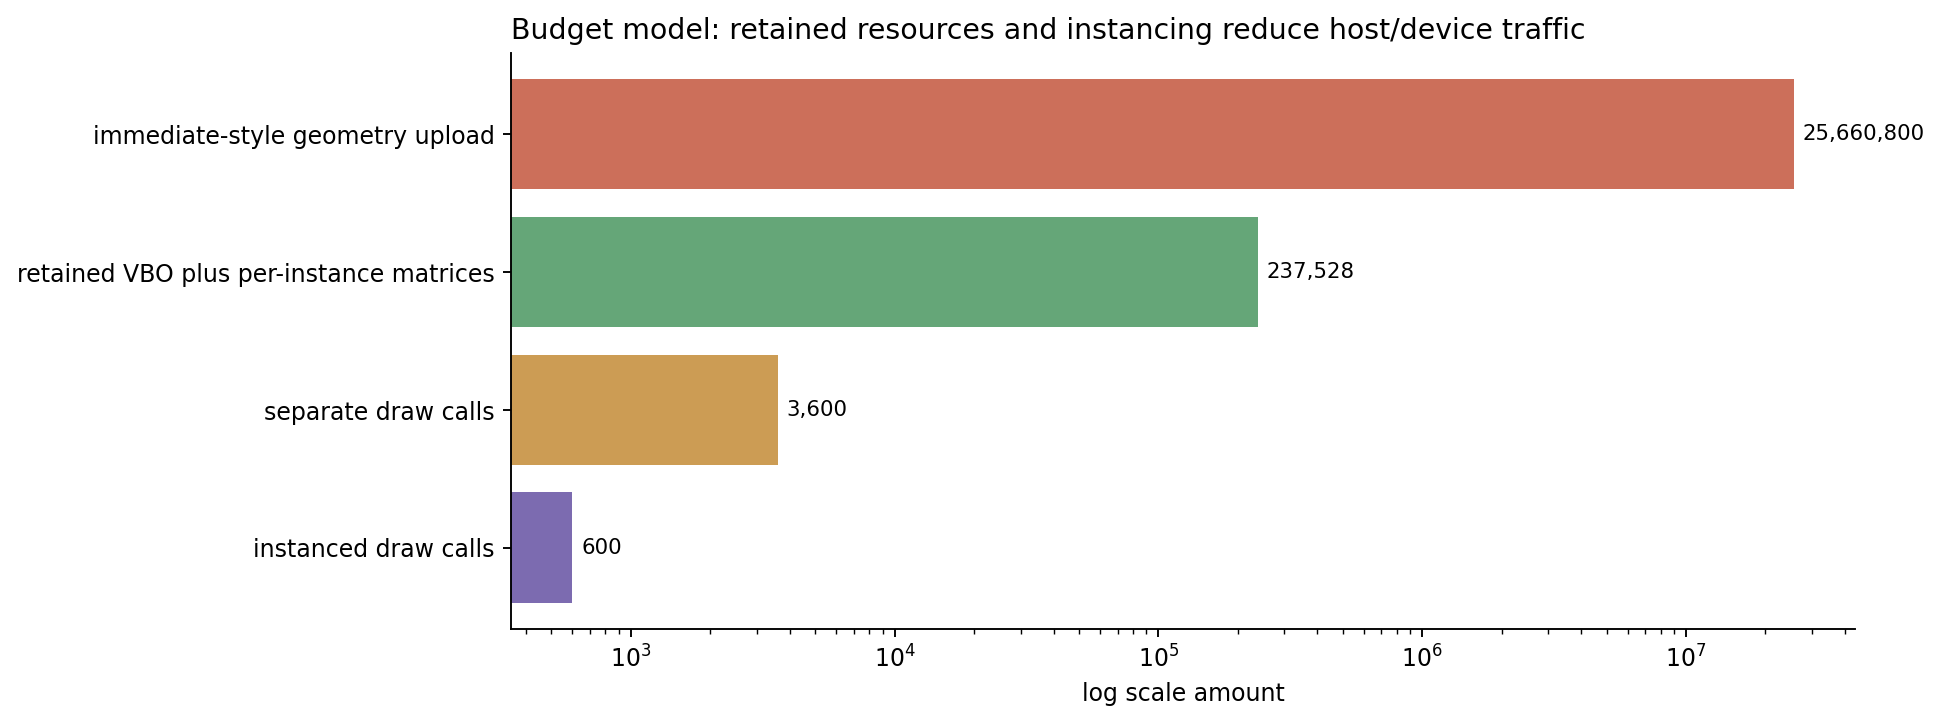

,symptom,first_debug_view,likely_state_to_check
0,blank frame,clear color and flat fragment shader,"context exists, shader linked, framebuffer bou..."
1,mesh explodes or colors scramble,attribute color or UV gradient,"VAO stride, offsets, component counts, index type"
2,lighting is black or inside-out,normal shader,"normal matrix, winding/culling, light uniforms"
3,object disappears behind another,depth buffer grayscale,"depth range, clear depth, comparison function,..."
4,texture smears or tiles unexpectedly,UV as color and sampler test texture,"wrap mode, filtering, bound texture unit, coor..."


In [18]:
display_artifact(performance_fig, width=820)
display(pd.DataFrame(debug_rows))
display_artifact(performance_check)


## Applied lab: Diagnose a Draw Call Before Rewriting Code

A practical hardware-programming habit is to reduce a bad frame to a minimal state checklist. The following tiny diagnostic function is intentionally ordinary Python: it mirrors the decision tree you would use with OpenGL debug output, a frame debugger, or one-off visual shaders.

Change one of the case dictionaries and rerun the cell. A good diagnosis should name the earliest failing contract: context, program, vertex array, transform, texture/sampler, or depth/stencil state.


In [19]:
def diagnose_draw_state(state):
    messages = []
    if not state.get("context_current", False):
        messages.append("No current graphics context: API calls cannot affect the intended device state.")
        return messages
    if not state.get("shader_linked", False): messages.append("Shader program is not linked; draw cannot run programmable stages.")
    if not state.get("vao_bound", False): messages.append("No VAO bound; vertex attributes have no active format contract.")
    if state.get("vertex_count", 0) <= 0: messages.append("Draw call has no vertices or indices.")
    if state.get("clip_w_min", 1.0) <= 0 or not state.get("inside_clip", False): messages.append("Transform debug: vertices are outside clip space or behind the eye.")
    if state.get("uses_texture", False) and not state.get("texture_bound", False): messages.append("Texture shader path has no texture bound to the expected unit.")
    if state.get("depth_test", False) and not state.get("depth_cleared", False): messages.append("Depth test enabled but depth buffer was not cleared for this frame.")
    if not messages: messages.append("Core state contracts pass; inspect shader math, uniforms, and resource contents next.")
    return messages

lab_cases = [
    {"case": "healthy instanced draw", "context_current": True, "shader_linked": True, "vao_bound": True, "vertex_count": len(base_vertices), "inside_clip": True, "clip_w_min": 0.7, "uses_texture": False, "texture_bound": False, "depth_test": True, "depth_cleared": True},
    {"case": "blank after refactor", "context_current": True, "shader_linked": False, "vao_bound": True, "vertex_count": len(base_vertices), "inside_clip": True, "clip_w_min": 0.7, "uses_texture": False, "texture_bound": False, "depth_test": True, "depth_cleared": True},
    {"case": "textured plane turns white", "context_current": True, "shader_linked": True, "vao_bound": True, "vertex_count": 6, "inside_clip": True, "clip_w_min": 0.9, "uses_texture": True, "texture_bound": False, "depth_test": True, "depth_cleared": True},
    {"case": "geometry vanished", "context_current": True, "shader_linked": True, "vao_bound": True, "vertex_count": len(base_vertices), "inside_clip": False, "clip_w_min": -0.2, "uses_texture": False, "texture_bound": False, "depth_test": True, "depth_cleared": True},
]
lab_rows = [{"case": case["case"], "diagnosis": " | ".join(diagnose_draw_state(case))} for case in lab_cases]
lab_table = save_table(lab_rows, "draw-state-diagnostic-lab.csv")
display(pd.DataFrame(lab_rows))
display_artifact(lab_table)


,case,diagnosis
0,healthy instanced draw,Core state contracts pass; inspect shader math...
1,blank after refactor,Shader program is not linked; draw cannot run ...
2,textured plane turns white,Texture shader path has no texture bound to th...
3,geometry vanished,Transform debug: vertices are outside clip spa...


## Takeaways

1. Treat the GPU as a separate device with resident resources and explicit state.
2. Separate storage from interpretation: VBOs store bytes; VAOs explain those bytes to shader inputs.
3. Make every transform visible at least once: world coordinates, clip `w`, NDC range, viewport mapping, and depth.
4. Debug hidden buffers and shader inputs by turning them into colors: normals, UVs, depth, stencil, and attribute streams.
5. Reuse data aggressively. Retained buffers, textures, and instanced meshes are the normal path; repeated host uploads are a warning sign.
6. Keep a small set of invariants in your workflow. They catch the same failures that otherwise show up as a blank or corrupted frame.


## Sanity checks

The final cell asserts the core pipeline, buffer, transform, rasterization, texture, instancing, and performance invariants, then verifies that every chapter-17 artifact exists and has nonzero size.


In [20]:
# Final sanity checks: artifact existence, nonzero sizes, and the core invariants this notebook teaches.
assert pipeline_checks["has_application_to_display_path"]
assert buffer_checks["stride_matches_dtype_itemsize"]
assert buffer_checks["wrong_stride_color_error_l2"] > 0.1
assert transform_checks["clip_w_all_positive"]
assert transform_checks["all_vertices_inside_clip_cube"]
assert raster_checks["sample_inside_both_triangles"]
assert raster_checks["sample_winner_triangle_id"] == 2
assert raster_checks["max_barycentric_sum_error"] < 1e-9
assert attr_checks["mean_abs_bug_image_difference"] > 0.03
assert texture_checks["repeat_periodic_sample_equal"]
assert texture_checks["clamp_border_sample_equal"]
assert instancing_checks["vertex_upload_reduction_fraction"] > 0.75
assert instancing_checks["all_model_linear_parts_invertible"]
assert performance_checks["retained_upload_is_smaller"]
assert performance_checks["instancing_reduces_draw_calls"]
final_summary = {
    "chapter": CHAPTER,
    "title": TITLE,
    "source_span": "printed pp. 461-502 / PDF pp. 478-519",
    "artifact_count_before_final": len(artifact_paths),
    "checks": {
        "pipeline_path": pipeline_checks["path_application_to_display"],
        "stride_bytes": buffer_checks["stride_bytes"],
        "ndc_min": transform_checks["ndc_min"],
        "ndc_max": transform_checks["ndc_max"],
        "sample_depth_winner": raster_checks["sample_winner_triangle_id"],
        "instance_count": instancing_checks["instance_count"],
        "retained_upload_ratio": performance_checks["retained_geometry_upload_bytes"] / performance_checks["naive_geometry_upload_bytes"],
    },
}
final_check = save_check("final-sanity.json", final_summary)
all_records = assert_artifacts([*artifact_paths, final_check], min_bytes=900)
print(f"Validated {len(all_records)} chapter-17 artifacts.")
display(pd.DataFrame(all_records))
display_artifact(final_check)


Validated 26 chapter-17 artifacts.


,path,bytes
0,artifacts/chapter-17/figures/gpu-pipeline-stat...,83956
1,artifacts/chapter-17/tables/pipeline-state-con...,833
2,artifacts/chapter-17/checks/pipeline-state-con...,531
3,artifacts/chapter-17/tables/vao-attribute-stat...,203
4,artifacts/chapter-17/figures/vertex-buffer-arr...,58746
5,artifacts/chapter-17/checks/buffer-vao-layout-...,395
6,artifacts/chapter-17/html/model-view-projectio...,12500
7,artifacts/chapter-17/figures/clip-space-viewpo...,75503
8,artifacts/chapter-17/checks/model-view-project...,378
9,artifacts/chapter-17/figures/depth-stencil-ras...,298044
